# EDA — IEEE-CIS Fraud Detection

This notebook explores the [IEEE-CIS Fraud Detection](https://www.kaggle.com/competitions/ieee-fraud-detection) dataset to:

1. Understand the structure (shape, dtypes, missing values)
2. Quantify the **class imbalance** (fraud rate)
3. Profile key features (transaction amount, time, product type, cards)
4. Identify candidate features and risks for the modeling phase

> **Memory-safe design.** The raw CSVs are large (~1.3 GB). Loading them naively in pandas spikes RAM to several GB. Instead we first convert them to compact Parquet (`python -m src.data.make_parquet`), then in this notebook we (a) read **missing-value statistics from Parquet metadata without loading any data**, and (b) load only the handful of columns each plot needs. Peak RAM stays well under 200 MB.

In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyarrow.parquet as pq
import seaborn as sns

# Make `src` importable when the notebook lives in notebooks/
sys.path.insert(0, str(Path.cwd().parent))
from src.config import PROCESSED_DATA_DIR  # noqa: E402

plt.rcParams["figure.figsize"] = (10, 5)
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)

TX_PATH = PROCESSED_DATA_DIR / "train_transaction.parquet"
ID_PATH = PROCESSED_DATA_DIR / "train_identity.parquet"

assert TX_PATH.exists(), (
    f"{TX_PATH} not found. Run `python -m src.data.make_parquet` first."
)
print("transaction parquet:", TX_PATH)
print("identity parquet:   ", ID_PATH)

transaction parquet: /mnt/c/Users/oallouch/fraud-detection-mlops/data/processed/train_transaction.parquet
identity parquet:    /mnt/c/Users/oallouch/fraud-detection-mlops/data/processed/train_identity.parquet


## 1. Dataset structure

The IEEE-CIS dataset ships as two paired tables, joined on `TransactionID`:

| Table | Rows | Description |
|---|---|---|
| `train_transaction` | 590 540 | One row per transaction, with the target `isFraud` |
| `train_identity` | 144 233 | Optional device / network metadata (~24 % of transactions) |

We read the **schema and row counts from Parquet metadata only** — this touches no actual data, so it is instant and memory-free.

In [2]:
tx_meta = pq.read_metadata(TX_PATH)
id_meta = pq.read_metadata(ID_PATH)

n_tx = tx_meta.num_rows
n_id = id_meta.num_rows

print(f"transaction: {n_tx:,} rows x {tx_meta.num_columns} columns")
print(f"identity:    {n_id:,} rows x {id_meta.num_columns} columns")
print(f"identity coverage: {n_id / n_tx:.1%} of transactions have identity data")

transaction: 590,540 rows x 394 columns
identity:    144,233 rows x 41 columns
identity coverage: 24.4% of transactions have identity data


## 2. Class imbalance

Fraud is rare. A trivial model that always predicts "not fraud" would already score ~96.5 % accuracy — so **accuracy is useless** for this problem. We will instead evaluate with:

- **AUC-PR** (precision–recall AUC) — robust under heavy imbalance
- **Recall at fixed precision** — the kind of metric a fraud ops team actually cares about
- **F1** — as a secondary balance metric

We load only the `isFraud` column.

Fraud rate: 3.50%
isFraud
not fraud    569877
fraud         20663
Name: count, dtype: int64


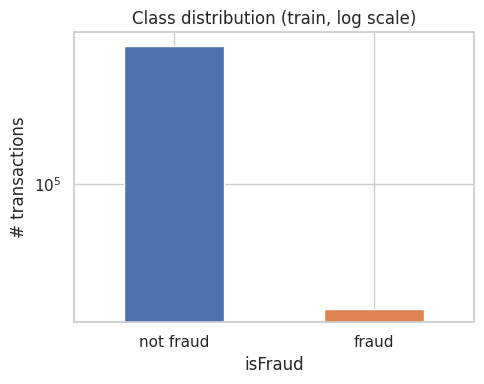

In [3]:
y = pq.read_table(TX_PATH, columns=["isFraud"]).to_pandas()["isFraud"]

fraud_rate = y.mean()
counts = y.value_counts().rename({0: "not fraud", 1: "fraud"})

print(f"Fraud rate: {fraud_rate:.2%}")
print(counts)

fig, ax = plt.subplots(figsize=(5, 4))
counts.plot(kind="bar", ax=ax, color=["#4c72b0", "#dd8452"])
ax.set_title("Class distribution (train, log scale)")
ax.set_ylabel("# transactions")
ax.set_yscale("log")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 3. Missing values

A defining property of this dataset is its **sparsity**: many engineered `V*`, `D*`, `M*` columns are missing for most rows. We compute the per-column missing rate **directly from Parquet metadata** (each column chunk stores its `null_count`), so we never load the data itself.

Knowing which columns are mostly empty helps us decide whether to impute, add an `is_missing` flag, or let a tree-based model (XGBoost) handle NaNs natively.

Transaction columns:            394
Columns with any missing value: 361
Columns with >50% missing:      169
Columns with >90% missing:      2

Top 15 most-missing columns:
dist2    93.6%
D7       93.4%
D13      89.5%
D14      89.5%
D12      89.0%
D6       87.6%
D9       87.3%
D8       87.3%
V148     86.1%
V142     86.1%
V141     86.1%
V147     86.1%
V146     86.1%
V158     86.1%
V149     86.1%
dtype: object


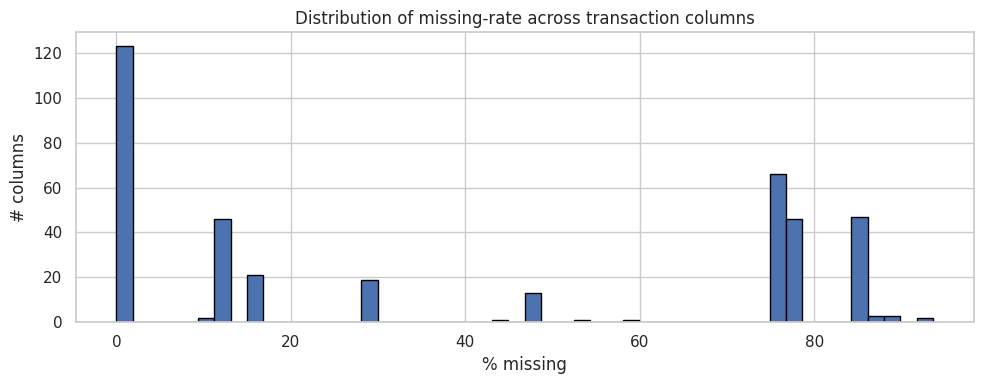

In [4]:
def missing_rates(meta: pq.FileMetaData) -> pd.Series:
    """Per-column missing rate, read from Parquet column statistics only."""
    null_counts: dict[str, int] = {}
    for rg in range(meta.num_row_groups):
        row_group = meta.row_group(rg)
        for c in range(meta.num_columns):
            col = row_group.column(c)
            name = col.path_in_schema
            null_counts[name] = null_counts.get(name, 0) + col.statistics.null_count
    return (pd.Series(null_counts) / meta.num_rows).sort_values(ascending=False)


missing = missing_rates(tx_meta)

print(f"Transaction columns:            {len(missing)}")
print(f"Columns with any missing value: {(missing > 0).sum()}")
print(f"Columns with >50% missing:      {(missing > 0.5).sum()}")
print(f"Columns with >90% missing:      {(missing > 0.9).sum()}")
print("\nTop 15 most-missing columns:")
print(missing.head(15).map(lambda x: f"{x:.1%}"))

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(missing.values * 100, bins=50, color="#4c72b0", edgecolor="black")
ax.set_xlabel("% missing")
ax.set_ylabel("# columns")
ax.set_title("Distribution of missing-rate across transaction columns")
plt.tight_layout()
plt.show()

## 4. Transaction amount

`TransactionAmt` is one of the few always-present, interpretable continuous features. Its distribution is heavily right-skewed, so a `log1p` transform makes the comparison readable. We load just `isFraud` and `TransactionAmt`.

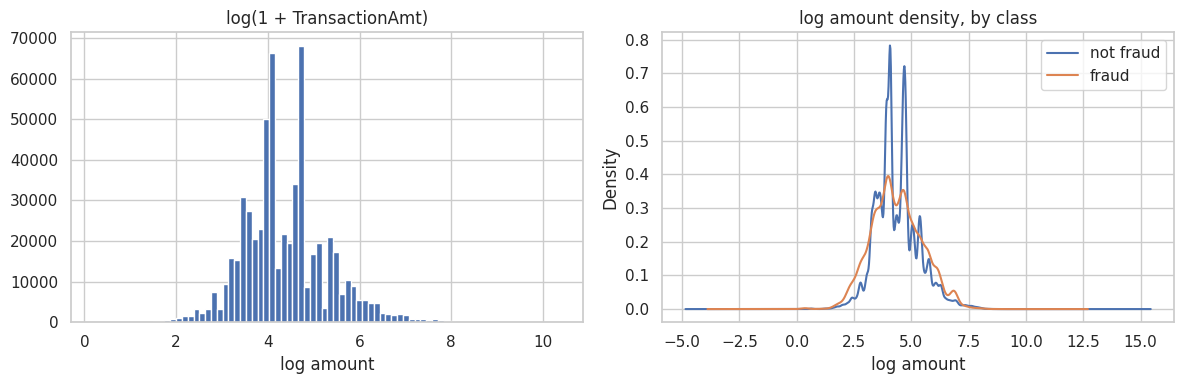

TransactionAmt summary by class:
               mean   50%           max
isFraud                                
0        134.511658  68.5  31937.390625
1        149.244781  75.0   5191.000000


In [5]:
amt = pq.read_table(TX_PATH, columns=["isFraud", "TransactionAmt"]).to_pandas()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

np.log1p(amt["TransactionAmt"]).hist(bins=80, ax=axes[0], color="#4c72b0")
axes[0].set_title("log(1 + TransactionAmt)")
axes[0].set_xlabel("log amount")

for label, color, name in [(0, "#4c72b0", "not fraud"), (1, "#dd8452", "fraud")]:
    np.log1p(amt.loc[amt["isFraud"] == label, "TransactionAmt"]).plot(
        kind="kde", ax=axes[1], label=name, color=color
    )
axes[1].set_title("log amount density, by class")
axes[1].set_xlabel("log amount")
axes[1].legend()

plt.tight_layout()
plt.show()

print("TransactionAmt summary by class:")
print(amt.groupby("isFraud")["TransactionAmt"].describe()[["mean", "50%", "max"]])

## 5. Temporal pattern

`TransactionDT` is a continuous offset in seconds from a reference date (Kaggle anonymized the absolute date). We convert it to a **day index** to inspect daily volume and daily fraud rate.

**Why this matters for modeling**: if the fraud rate or feature distributions drift over time, a *random* train/validation split leaks future information. We should split **temporally** instead.

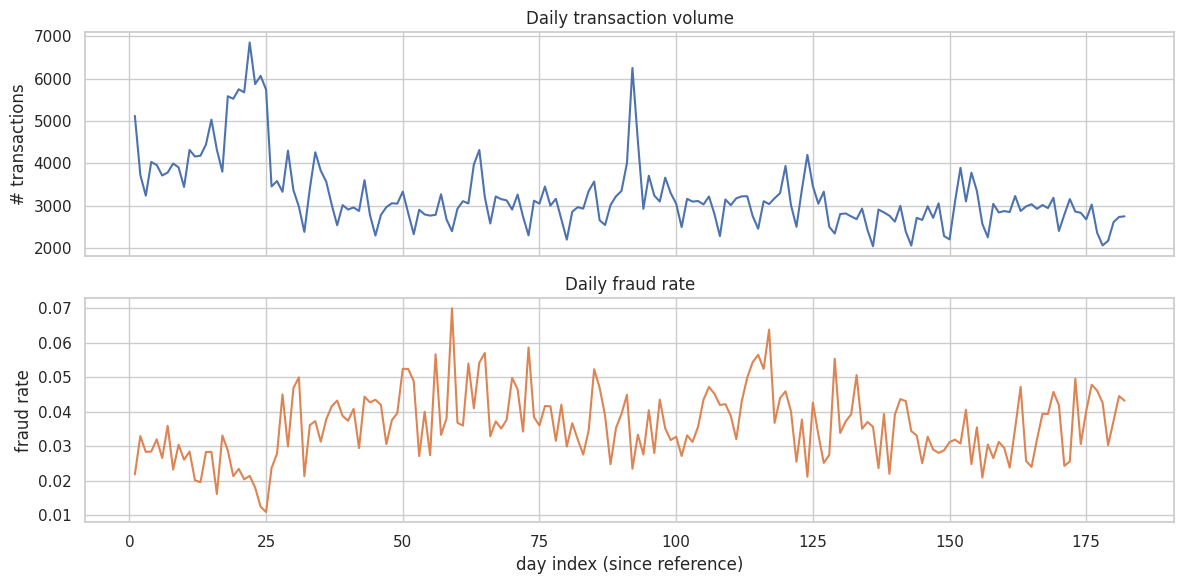

Time span covered: 182 days


In [6]:
t = pq.read_table(TX_PATH, columns=["isFraud", "TransactionDT"]).to_pandas()
t["dt_day"] = (t["TransactionDT"] // (60 * 60 * 24)).astype("int32")

daily_volume = t.groupby("dt_day").size()
daily_fraud_rate = t.groupby("dt_day")["isFraud"].mean()

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
daily_volume.plot(ax=axes[0], color="#4c72b0")
axes[0].set_title("Daily transaction volume")
axes[0].set_ylabel("# transactions")

daily_fraud_rate.plot(ax=axes[1], color="#dd8452")
axes[1].set_title("Daily fraud rate")
axes[1].set_ylabel("fraud rate")
axes[1].set_xlabel("day index (since reference)")

plt.tight_layout()
plt.show()

print(f"Time span covered: {t['dt_day'].max() - t['dt_day'].min() + 1} days")

## 6. Categorical signals: product and card

A few well-populated categorical columns can carry strong signal:

- `ProductCD` — high-level product category
- `card4` — issuer brand (Visa, MasterCard, ...)
- `card6` — debit vs credit

We compare the per-category **fraud rate** against the overall rate. Categories with sharply higher rates are strong candidates for **target encoding** or one-hot encoding in Phase 2.

In [7]:
cat = pq.read_table(
    TX_PATH, columns=["isFraud", "ProductCD", "card4", "card6"]
).to_pandas()

for col in ["ProductCD", "card4", "card6"]:
    summary = (
        cat.groupby(col, dropna=False)
        .agg(volume=("isFraud", "size"), fraud_rate=("isFraud", "mean"))
        .sort_values("volume", ascending=False)
    )
    summary["fraud_rate"] = summary["fraud_rate"].map(lambda x: f"{x:.2%}")
    print(f"\n=== {col} ===")
    print(summary.head(10))


=== ProductCD ===
           volume fraud_rate
ProductCD                   
W          439670      2.04%
C           68519     11.69%
R           37699      3.78%
H           33024      4.77%
S           11628      5.90%

=== card4 ===
                  volume fraud_rate
card4                              
visa              384767      3.48%
mastercard        189217      3.43%
american express    8328      2.87%
discover            6651      7.73%
                    1577      2.60%

=== card6 ===
                 volume fraud_rate
card6                             
debit            439938      2.43%
credit           148986      6.68%
                   1571      2.48%
debit or credit      30      0.00%
charge card          15      0.00%


## 7. Findings & next steps

**Key takeaways for modeling**

- **Extreme class imbalance** (~3.5 % fraud) → rely on **AUC-PR** and **recall at fixed precision**, not accuracy. Use class weighting / `scale_pos_weight` for XGBoost.
- **Sparsity is the norm** — 169 of 394 columns are >50 % missing (mostly `V*`/`D*`). Let XGBoost handle NaN natively; add missingness indicators where absence looks predictive.
- **TransactionAmt is heavily right-skewed** — add a `log1p` feature; the conditional distribution differs between classes, so the raw column is informative too.
- **Likely temporal drift** — daily volume and fraud rate are not flat over the 182-day span. Split train/validation **temporally** to mimic deployment and avoid leakage.
- **Categorical features carry strong signal** — `ProductCD = C` has an 11.7 % fraud rate (vs 2.0 % for `W`), and credit cards (6.7 %) are far riskier than debit (2.4 %). Good candidates for target/one-hot encoding.

**Coming next (Phase 2)**

1. `src/features/build_features.py` — reusable feature engineering pipeline
2. `src/models/baseline.py` — logistic-regression baseline for sanity
3. `src/models/xgboost_model.py` — supervised XGBoost with **MLflow tracking**
4. `src/models/isolation_forest.py` and `src/models/autoencoder.py` — unsupervised approaches
5. Temporal validation split + AUC-PR / F1 / recall reporting